# 04 — Inflammatory Subtype Clustering

Cluster participants by their inflammatory biomarker profile and characterise depression phenotypes within each cluster.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import kruskal
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
PROCESSED = Path('../data/processed')
FIGURES   = Path('../figures')

df = pd.read_parquet(PROCESSED / 'nhanes_analysis_ready.parquet', engine='fastparquet')

MARKERS = ['log_CRP', 'log_WBC', 'LBXNEPCT', 'LBXLYPCT',
           'log_NLR', 'LBXSAL', 'log_ferritin']
MARKER_LABELS = {
    'log_CRP':      'CRP (log)',
    'log_WBC':      'WBC (log)',
    'LBXNEPCT':     'Neutrophil %',
    'LBXLYPCT':     'Lymphocyte %',
    'log_NLR':      'NLR (log)',
    'LBXSAL':       'Albumin',
    'log_ferritin': 'Ferritin (log)',
}
PHQ_ITEMS = [f'DPQ0{i}0' for i in range(1, 10)]
ITEM_LABELS = {
    'DPQ010': 'Anhedonia',    'DPQ020': 'Depressed mood', 'DPQ030': 'Sleep',
    'DPQ040': 'Fatigue',      'DPQ050': 'Appetite',        'DPQ060': 'Self-worth',
    'DPQ070': 'Concentration','DPQ080': 'Psychomotor',     'DPQ090': 'Suicidality',
}

X        = df[MARKERS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'N = {len(df):,}, biomarker features = {X.shape[1]}')

N = 1,689, biomarker features = 7


## 1. Determine Optimal Number of Clusters (k = 2 to 6)

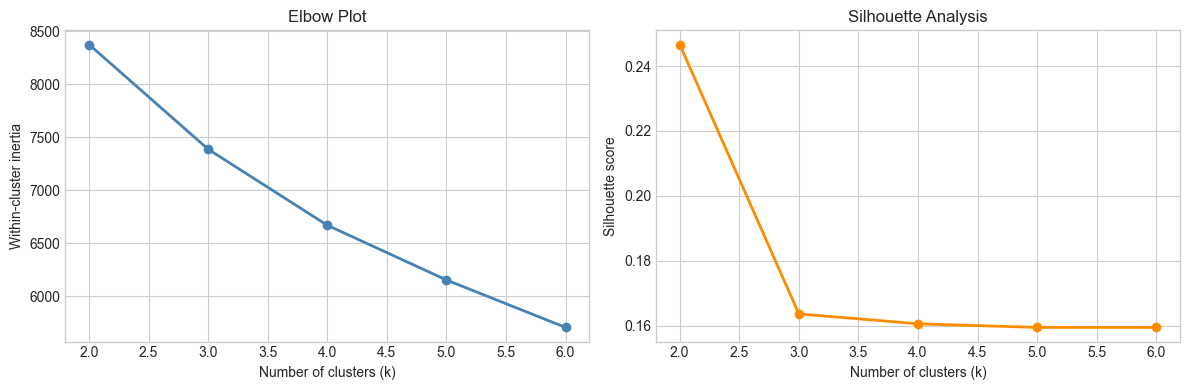

Optimal k (max silhouette): 2
  k=2: silhouette=0.2466
  k=3: silhouette=0.1636
  k=4: silhouette=0.1605
  k=5: silhouette=0.1594
  k=6: silhouette=0.1594


In [ ]:
k_range     = range(2, 7)
inertias    = []
silhouettes = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, 'o-', color='#CA5995', linewidth=2)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Within-cluster inertia')
ax1.set_title('Elbow Plot')

ax2.plot(list(k_range), silhouettes, 'o-', color='#5D1C6A', linewidth=2)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette Analysis')

plt.tight_layout()
plt.savefig(FIGURES / 'clustering_selection.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Optimal k (max silhouette): {optimal_k}')
for k, s in zip(k_range, silhouettes):
    print(f'  k={k}: silhouette={s:.4f}')

## 2. Fit K-Means with Optimal k

In [10]:
K  = optimal_k   # set manually here if you want to override
km = KMeans(n_clusters=K, random_state=42, n_init=50)
df['cluster'] = km.fit_predict(X_scaled)

print(f'K-means solution: k={K}')
print(df['cluster'].value_counts().sort_index().rename('N').to_frame())
print()
print('Depression prevalence (%) by cluster:')
print((df.groupby('cluster')['depression'].mean() * 100).round(1).to_string())

K-means solution: k=2
           N
cluster     
0        869
1        820

Depression prevalence (%) by cluster:
cluster
0    14.0
1    12.4


## 3. PCA Visualisation of Clusters

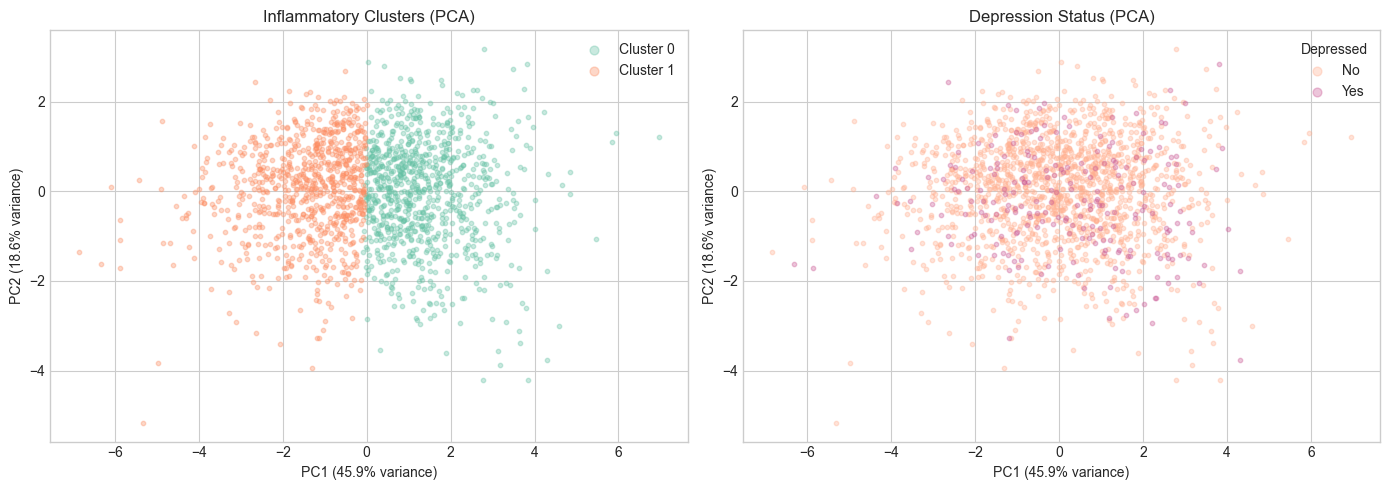

PCA loadings (marker contributions):
                  PC1    PC2
CRP (log)       0.173 -0.652
WBC (log)       0.301 -0.158
Neutrophil %    0.539  0.135
Lymphocyte %   -0.534 -0.143
NLR (log)       0.543  0.139
Albumin        -0.083  0.689
Ferritin (log) -0.054  0.134


In [ ]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1':        X_pca[:, 0],
    'PC2':        X_pca[:, 1],
    'cluster':    df['cluster'].astype(str),
    'depression': df['depression'].map({0.0: 'No', 1.0: 'Yes'}),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_k = sns.color_palette('Set2', K)

for k, color in zip(sorted(pca_df['cluster'].unique()), palette_k):
    sub = pca_df[pca_df['cluster'] == k]
    axes[0].scatter(sub['PC1'], sub['PC2'], c=[color], alpha=0.35, s=10, label=f'Cluster {k}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Inflammatory Clusters (PCA)')
axes[0].legend(markerscale=2)

for dep, color in [('No', '#FFB090'), ('Yes', '#5D1C6A')]:
    sub = pca_df[pca_df['depression'] == dep]
    axes[1].scatter(sub['PC1'], sub['PC2'], c=color, alpha=0.35, s=10, label=dep)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('Depression Status (PCA)')
axes[1].legend(title='Depressed', markerscale=2)

plt.tight_layout()
plt.savefig(FIGURES / 'pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('PCA loadings (marker contributions):')
loadings = pd.DataFrame(pca.components_.T,
                         index=list(MARKER_LABELS.values()),
                         columns=['PC1', 'PC2'])
print(loadings.round(3).to_string())

## 4. Cluster Inflammatory Profiles

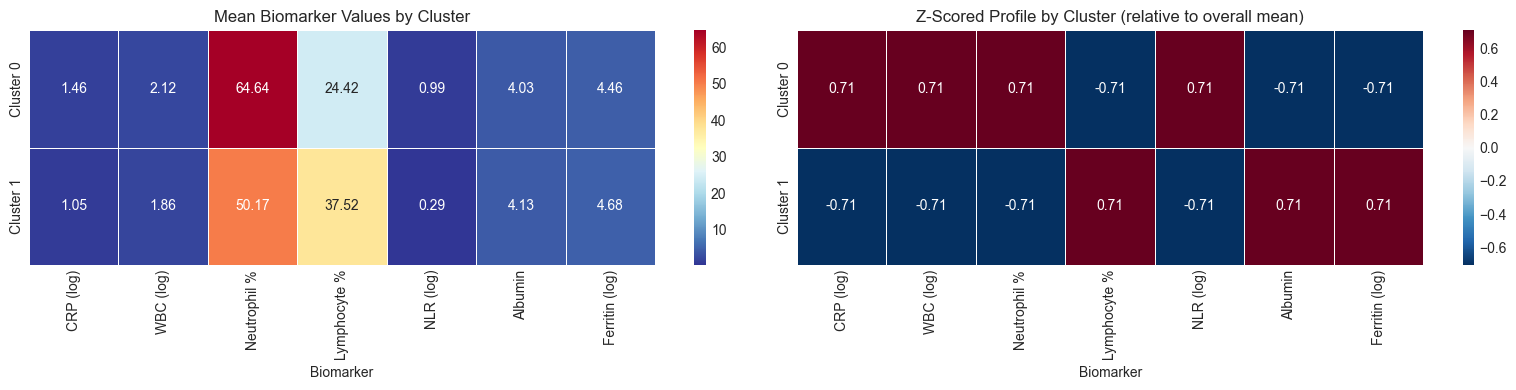

In [12]:
cluster_means = df.groupby('cluster')[MARKERS].mean()
cluster_means.index   = [f'Cluster {i}' for i in cluster_means.index]
cluster_means.columns = list(MARKER_LABELS.values())

cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, axes = plt.subplots(1, 2, figsize=(16, max(3, K + 2)))
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap='RdYlBu_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Biomarker Values by Cluster')
axes[0].set_xlabel('Biomarker')

sns.heatmap(cluster_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Z-Scored Profile by Cluster (relative to overall mean)')
axes[1].set_xlabel('Biomarker')

plt.tight_layout()
plt.savefig(FIGURES / 'cluster_biomarker_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PHQ-9 Profiles by Cluster

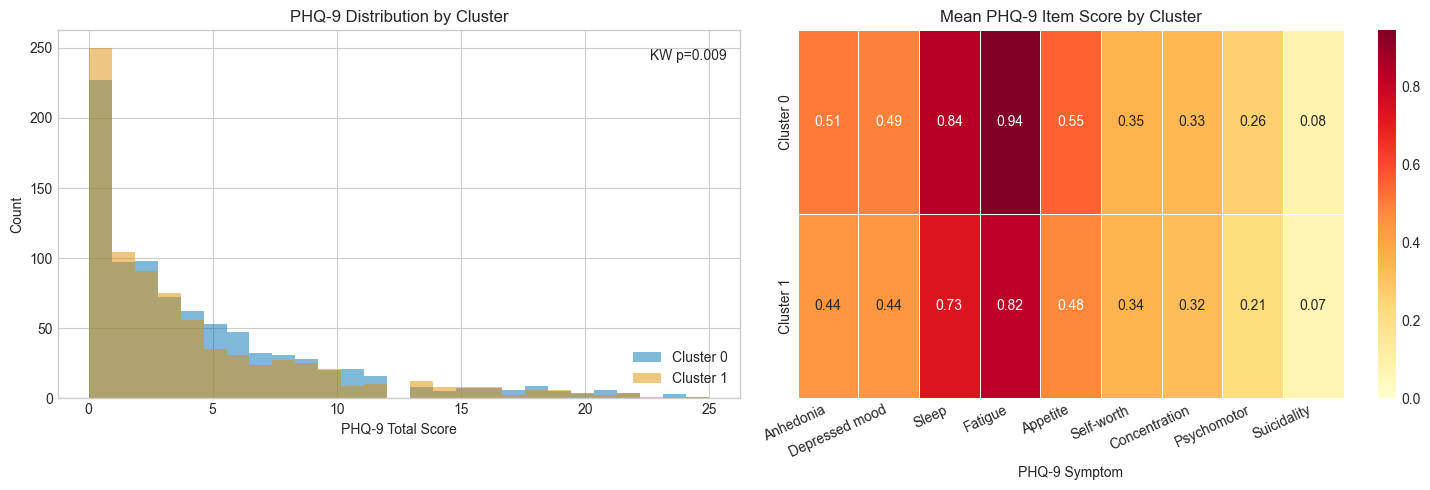

Cluster summary:
           N  PHQ9_mean  PHQ9_sd  depression_pct
cluster                                         
0        869       4.36     5.03           14.04
1        820       3.86     4.85           12.44


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for k in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == k]['PHQ9_total'].dropna()
    axes[0].hist(sub, bins=27, alpha=0.5, label=f'Cluster {k}')
axes[0].set_xlabel('PHQ-9 Total Score')
axes[0].set_ylabel('Count')
axes[0].set_title('PHQ-9 Distribution by Cluster')
axes[0].legend()

groups_kw = [df[df['cluster'] == k]['PHQ9_total'].dropna().values
             for k in sorted(df['cluster'].unique())]
stat, p_kw = kruskal(*groups_kw)
axes[0].text(0.98, 0.95, f'KW p={p_kw:.3f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10)

item_by_cluster = df.groupby('cluster')[PHQ_ITEMS].mean()
item_by_cluster.index   = [f'Cluster {i}' for i in item_by_cluster.index]
item_by_cluster.columns = list(ITEM_LABELS.values())
sns.heatmap(item_by_cluster, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Mean PHQ-9 Item Score by Cluster')
axes[1].set_xlabel('PHQ-9 Symptom')
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.savefig(FIGURES / 'phq9_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cluster summary:')
print(df.groupby('cluster').agg(
    N=('PHQ9_total', 'count'),
    PHQ9_mean=('PHQ9_total', 'mean'),
    PHQ9_sd=('PHQ9_total', 'std'),
    depression_pct=('depression', lambda x: x.mean() * 100),
).round(2).to_string())

## 6. Demographic Characteristics by Cluster

In [14]:
demo_by_cluster = df.groupby('cluster').agg(
    Age_mean=('RIDAGEYR', 'mean'),
    Female_pct=('RIAGENDR', lambda x: (x == 2).mean() * 100),
    BMI_mean=('BMXBMI', 'mean'),
    Smoker_pct=('SMQ040_bin', lambda x: x.mean() * 100),
    Alcohol_mean=('ALQ130', 'mean'),
).round(2)
demo_by_cluster.index = [f'Cluster {i}' for i in demo_by_cluster.index]
print(demo_by_cluster.to_string())

df[['SEQN', 'cluster']].to_csv(PROCESSED / 'cluster_assignments.csv', index=False)
print('Cluster assignments saved.')

           Age_mean  Female_pct  BMI_mean  Smoker_pct  Alcohol_mean
Cluster 0     48.99       51.09     31.45       50.86          2.93
Cluster 1     46.74       45.73     28.89       46.10          2.90
Cluster assignments saved.
